# Notebook 3: Exploratory Data Analysis
## Songwriter Style Analysis - Visualizations and Statistical Analysis

**Objective**: Analyze and visualize songwriter characteristics

**Input**: songs_preprocessed.csv (from Notebook 2)

**Outputs**: 
- Word clouds per songwriter
- Sentiment analysis charts
- Stylometric profiles
- Vocabulary analysis
- Statistical summaries

## Step 1: Import Libraries

In [30]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully")

Libraries imported successfully


## Step 2: Load Preprocessed Data

In [31]:
# Load preprocessed data
print("Loading preprocessed data...")
print("="*60)

df = pd.read_csv('data/songs_preprocessed.csv')

print(f"[SUCCESS] Loaded {len(df)} songs")
print(f"\nSongwriters: {df['target_songwriter'].nunique()}")
print(f"\nSongs per songwriter:")
print(df['target_songwriter'].value_counts())

print("\n" + "="*60)

Loading preprocessed data...
[SUCCESS] Loaded 208 songs

Songwriters: 7

Songs per songwriter:
target_songwriter
Jack Antonoff    50
Max Martin       46
Dr. Luke         25
Ryan Tedder      24
Diplo            22
Stargate         21
Sia Furler       20
Name: count, dtype: int64



## Step 3: Calculate Stylometric Features

In [40]:
# Calculate stylometric features for each song
print("Calculating stylometric features...")
print("="*60)

def calculate_stylometric_features(text):
    """
    Calculate stylometric features from text
    """
    words = text.split()
    
    if len(words) == 0:
        return {
            'word_count': 0,
            'unique_word_count': 0,
            'lexical_diversity': 0,
            'avg_word_length': 0,
            'word_length_variance': 0,
            'short_word_ratio': 0,
            'long_word_ratio': 0,
            'very_long_word_ratio': 0
        }
    
    unique_words = set(words)
    word_lengths = [len(word) for word in words]
    
    return {
        'word_count': len(words),
        'unique_word_count': len(unique_words),
        'lexical_diversity': len(unique_words) / len(words),
        'avg_word_length': np.mean(word_lengths),
        'word_length_variance': np.var(word_lengths),
        'short_word_ratio': sum(1 for w in words if len(w) <= 3) / len(words),
        'long_word_ratio': sum(1 for w in words if len(w) >= 7) / len(words),
        'very_long_word_ratio': sum(1 for w in words if len(w) >= 10) / len(words)
    }

# Apply to all songs
stylometric_features = df['lyrics_processed'].apply(calculate_stylometric_features)
stylometric_df = pd.DataFrame(stylometric_features.tolist())

# Drop existing word_count column to avoid conflicts
if 'word_count' in df.columns:
    df = df.drop('word_count', axis=1)

# Merge with main dataframe
df = pd.concat([df, stylometric_df], axis=1)

print("[SUCCESS] Stylometric features calculated")
print(f"\nFeatures added:")
for col in stylometric_df.columns:
    print(f"  - {col}")

print("\n" + "="*60)

Calculating stylometric features...
[SUCCESS] Stylometric features calculated

Features added:
  - word_count
  - unique_word_count
  - lexical_diversity
  - avg_word_length
  - word_length_variance
  - short_word_ratio
  - long_word_ratio
  - very_long_word_ratio



## Step 4: Calculate Sentiment Features

In [41]:
# Calculate sentiment features
print("Calculating sentiment features...")
print("="*60)

def get_sentiment(text):
    """
    Get sentiment polarity and subjectivity
    """
    try:
        blob = TextBlob(text)
        return blob.sentiment.polarity, blob.sentiment.subjectivity
    except:
        return 0, 0

# Calculate sentiment on clean lyrics (not preprocessed)
sentiments = df['lyrics_clean'].apply(get_sentiment)
df['sentiment_polarity'] = [s[0] for s in sentiments]
df['sentiment_subjectivity'] = [s[1] for s in sentiments]

# Categorize sentiment
df['sentiment_category'] = pd.cut(
    df['sentiment_polarity'],
    bins=[-1, -0.1, 0.1, 1],
    labels=['negative', 'neutral', 'positive']
)

print("[SUCCESS] Sentiment features calculated")
print(f"\nSentiment distribution:")
print(df['sentiment_category'].value_counts())

print("\n" + "="*60)

Calculating sentiment features...
[SUCCESS] Sentiment features calculated

Sentiment distribution:
sentiment_category
positive    106
neutral      86
negative     16
Name: count, dtype: int64



## Step 5: Vocabulary Analysis by Songwriter

In [42]:
# Analyze vocabulary characteristics by songwriter
print("Vocabulary Analysis by Songwriter")
print("="*60)

# Calculate aggregations
vocab_means = df.groupby('target_songwriter')[['word_count', 'unique_word_count', 'lexical_diversity', 'avg_word_length']].mean()
vocab_stds = df.groupby('target_songwriter')[['word_count', 'unique_word_count', 'lexical_diversity', 'avg_word_length']].std()

# Rename columns for clarity
vocab_means.columns = [col + '_mean' for col in vocab_means.columns]
vocab_stds.columns = [col + '_std' for col in vocab_stds.columns]

# Combine into single dataframe
vocab_analysis = pd.concat([vocab_means, vocab_stds], axis=1).round(2)

print(vocab_analysis)

# Save to CSV
vocab_analysis.to_csv('data/vocabulary_analysis.csv')
print("\n[SAVED] Vocabulary analysis saved to data/vocabulary_analysis.csv")

print("\n" + "="*60)

Vocabulary Analysis by Songwriter
                   word_count_mean  unique_word_count_mean  \
target_songwriter                                            
Diplo                       242.73                   92.68   
Dr. Luke                    209.72                   80.36   
Jack Antonoff               182.24                   81.38   
Max Martin                  197.83                   74.15   
Ryan Tedder                 185.92                   66.33   
Sia Furler                  196.65                   60.40   
Stargate                    231.33                   78.90   

                   unique_word_count_mean  lexical_diversity_mean  \
target_songwriter                                                   
Diplo                               92.68                    0.38   
Dr. Luke                            80.36                    0.38   
Jack Antonoff                       81.38                    0.46   
Max Martin                          74.15                    0

## Step 6: Sentiment Analysis by Songwriter

In [43]:
# Analyze sentiment by songwriter
print("Sentiment Analysis by Songwriter")
print("="*60)

sentiment_analysis = df.groupby('target_songwriter').agg({
    'sentiment_polarity': ['mean', 'std'],
    'sentiment_subjectivity': ['mean', 'std']
}).round(3)

print(sentiment_analysis)

# Save to CSV
sentiment_analysis.to_csv('data/sentiment_analysis.csv')
print("\n[SAVED] Sentiment analysis saved to data/sentiment_analysis.csv")

print("\n" + "="*60)

Sentiment Analysis by Songwriter
                  sentiment_polarity        sentiment_subjectivity       
                                mean    std                   mean    std
target_songwriter                                                        
Diplo                          0.071  0.159                  0.518  0.105
Dr. Luke                       0.079  0.146                  0.491  0.134
Jack Antonoff                  0.074  0.169                  0.506  0.111
Max Martin                     0.086  0.131                  0.521  0.127
Ryan Tedder                    0.132  0.135                  0.506  0.114
Sia Furler                     0.216  0.199                  0.563  0.128
Stargate                       0.115  0.157                  0.509  0.121

[SAVED] Sentiment analysis saved to data/sentiment_analysis.csv



## Step 7: Create Word Clouds for Each Songwriter

Generating word clouds...
  [OK] Word cloud created for Diplo
  [OK] Word cloud created for Dr. Luke
  [OK] Word cloud created for Jack Antonoff
  [OK] Word cloud created for Dr. Luke
  [OK] Word cloud created for Jack Antonoff
  [OK] Word cloud created for Max Martin
  [OK] Word cloud created for Ryan Tedder
  [OK] Word cloud created for Max Martin
  [OK] Word cloud created for Ryan Tedder
  [OK] Word cloud created for Sia Furler
  [OK] Word cloud created for Stargate
  [OK] Word cloud created for Sia Furler
  [OK] Word cloud created for Stargate

[SAVED] Word clouds saved to data/wordclouds.png

[SAVED] Word clouds saved to data/wordclouds.png


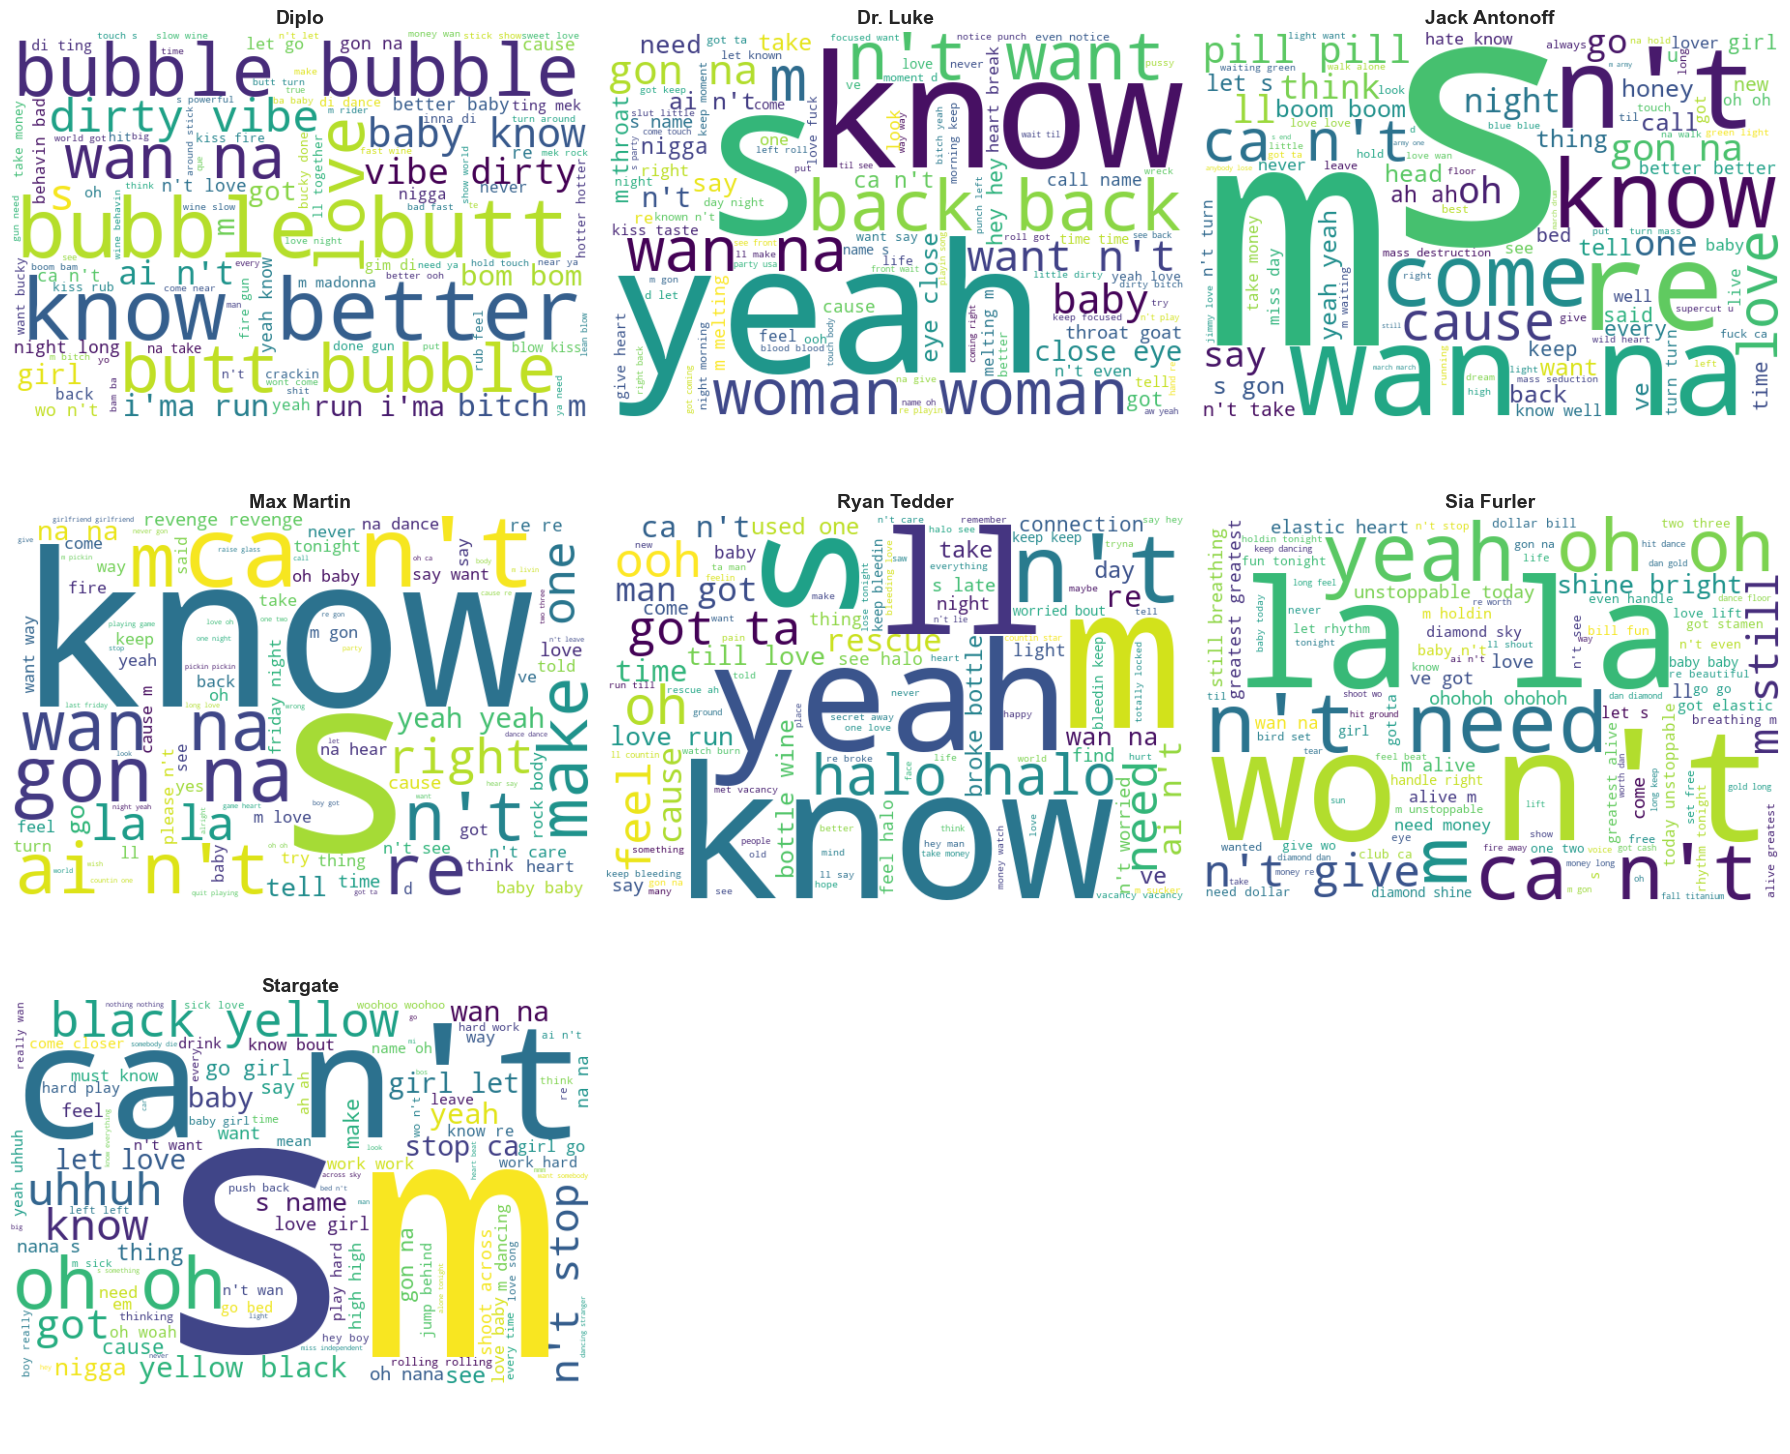

In [44]:
# Generate word clouds for each songwriter
print("Generating word clouds...")
print("="*60)

songwriters = df['target_songwriter'].unique()
n_writers = len(songwriters)

# Calculate grid dimensions
n_cols = 3
n_rows = (n_writers + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten() if n_writers > 1 else [axes]

for idx, songwriter in enumerate(sorted(songwriters)):
    # Combine all lyrics for this songwriter
    songwriter_lyrics = ' '.join(
        df[df['target_songwriter'] == songwriter]['lyrics_processed'].tolist()
    )
    
    # Generate word cloud
    wordcloud = WordCloud(
        width=600,
        height=400,
        background_color='white',
        colormap='viridis',
        max_words=100
    ).generate(songwriter_lyrics)
    
    # Plot
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(songwriter, fontsize=14, fontweight='bold')
    axes[idx].axis('off')
    
    print(f"  [OK] Word cloud created for {songwriter}")

# Hide unused subplots
for idx in range(n_writers, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('data/wordclouds.png', dpi=150, bbox_inches='tight')
print("\n[SAVED] Word clouds saved to data/wordclouds.png")
plt.show()

print("\n" + "="*60)

## Step 8: Sentiment Distribution Visualization

Creating sentiment visualizations...
[SAVED] Sentiment visualization saved to data/sentiment_visualization.png


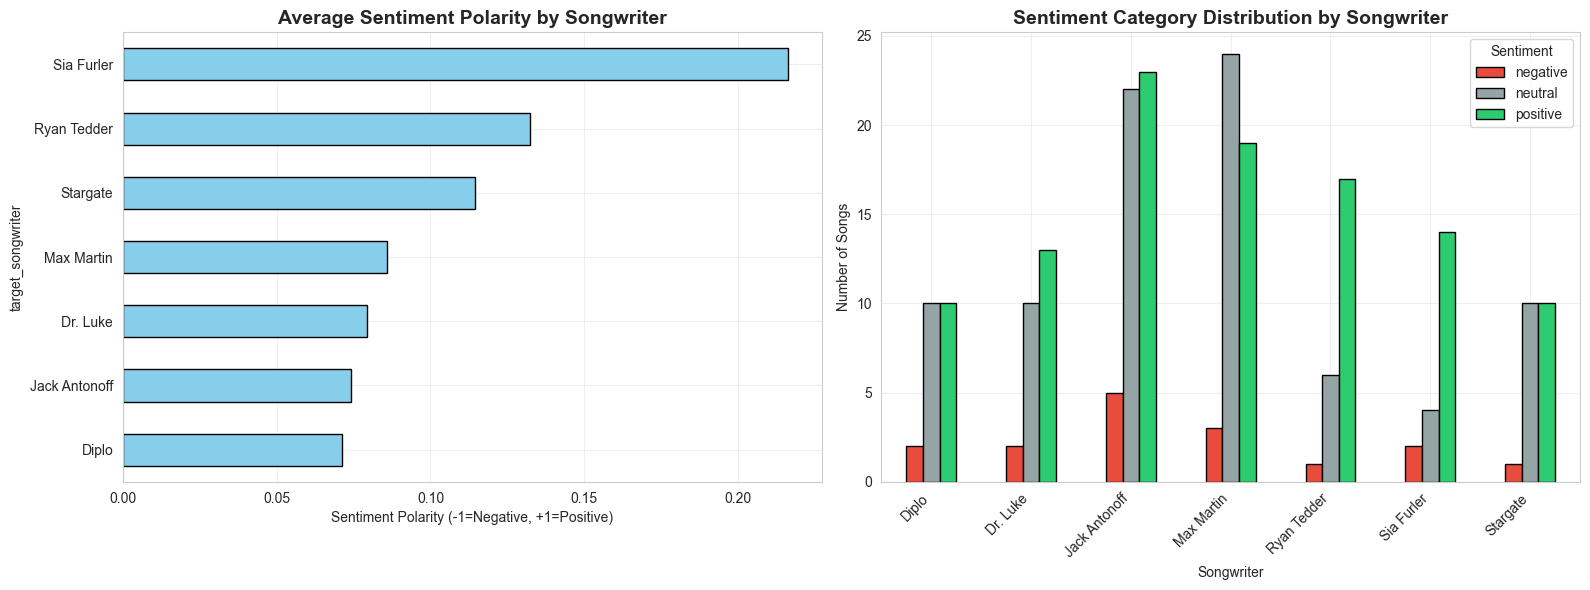

In [45]:
# Visualize sentiment distribution
print("Creating sentiment visualizations...")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Sentiment polarity by songwriter
df.groupby('target_songwriter')['sentiment_polarity'].mean().sort_values().plot(
    kind='barh',
    ax=axes[0],
    color='skyblue',
    edgecolor='black'
)
axes[0].set_title('Average Sentiment Polarity by Songwriter', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment Polarity (-1=Negative, +1=Positive)')
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)

# Plot 2: Sentiment category distribution
sentiment_counts = df.groupby(['target_songwriter', 'sentiment_category']).size().unstack(fill_value=0)
sentiment_counts.plot(
    kind='bar',
    ax=axes[1],
    stacked=False,
    color=['#e74c3c', '#95a5a6', '#2ecc71'],
    edgecolor='black',
    legend=True
)
axes[1].set_title('Sentiment Category Distribution by Songwriter', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Songwriter')
axes[1].set_ylabel('Number of Songs')
axes[1].legend(title='Sentiment', loc='upper right')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/sentiment_visualization.png', dpi=150, bbox_inches='tight')
print("[SAVED] Sentiment visualization saved to data/sentiment_visualization.png")
plt.show()

print("\n" + "="*60)

## Step 9: Stylometric Profiles Visualization

Creating stylometric profiles...


TypeError: DataFrame.sort_values() missing 1 required positional argument: 'by'

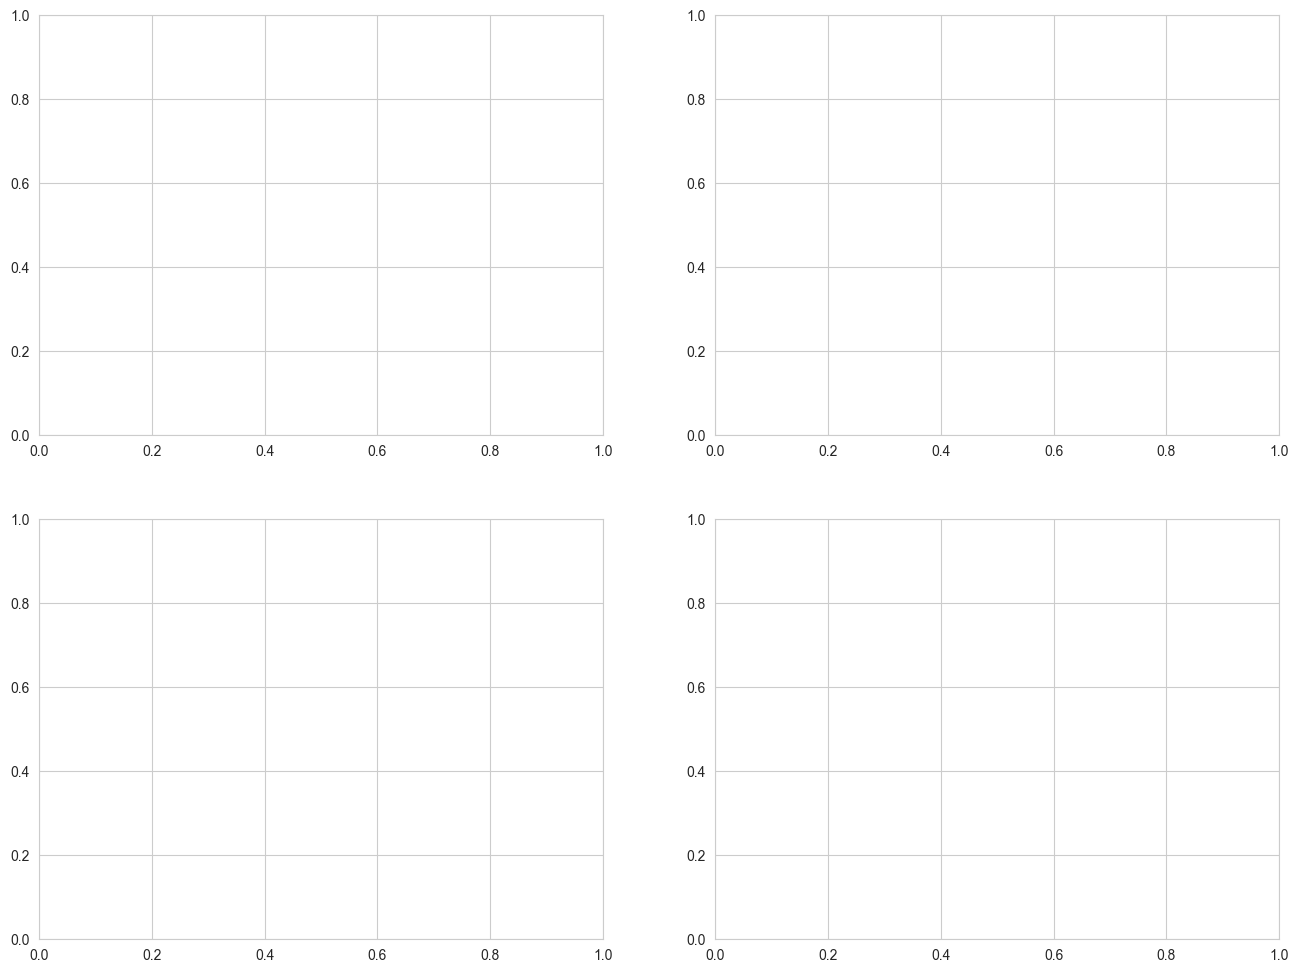

In [ ]:
# Create stylometric profiles visualization
print("Creating stylometric profiles...")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Calculate means for each metric
lexical_div = df.groupby('target_songwriter')['lexical_diversity'].mean()
avg_len = df.groupby('target_songwriter')['avg_word_length'].mean()
word_cnt = df.groupby('target_songwriter')['word_count'].mean()
long_ratio = df.groupby('target_songwriter')['long_word_ratio'].mean()

# Sort if they're Series, otherwise just use as-is
if isinstance(lexical_div, pd.Series):
    lexical_div = lexical_div.sort_values()
if isinstance(avg_len, pd.Series):
    avg_len = avg_len.sort_values()
if isinstance(word_cnt, pd.Series):
    word_cnt = word_cnt.sort_values()
if isinstance(long_ratio, pd.Series):
    long_ratio = long_ratio.sort_values()

# Plot 1: Lexical Diversity
lexical_div.plot(kind='barh', ax=axes[0, 0], color='coral', edgecolor='black')
axes[0, 0].set_title('Lexical Diversity (Vocabulary Richness)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Lexical Diversity Ratio')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Average Word Length
avg_len.plot(kind='barh', ax=axes[0, 1], color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Average Word Length', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Average Characters per Word')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Word Count
word_cnt.plot(kind='barh', ax=axes[1, 0], color='plum', edgecolor='black')
axes[1, 0].set_title('Average Song Length (Word Count)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Number of Words')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Long Word Ratio
long_ratio.plot(kind='barh', ax=axes[1, 1], color='khaki', edgecolor='black')
axes[1, 1].set_title('Long Word Usage (7+ Characters)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Ratio of Long Words')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/stylometric_profiles.png', dpi=150, bbox_inches='tight')
print("[SAVED] Stylometric profiles saved to data/stylometric_profiles.png")
plt.show()

print("\n" + "="*60)

## Step 10: Save Analysis Summary

In [39]:
# Create comprehensive analysis summary
print("Creating analysis summary...")
print("="*60)

# Calculate statistics
song_counts = df.groupby('target_songwriter').size().to_frame('song_count')
means = df.groupby('target_songwriter')[['word_count', 'unique_word_count', 'lexical_diversity', 
                                           'avg_word_length', 'sentiment_polarity', 'sentiment_subjectivity',
                                           'short_word_ratio', 'long_word_ratio']].mean()
stds = df.groupby('target_songwriter')[['word_count', 'unique_word_count', 'lexical_diversity',
                                          'avg_word_length', 'sentiment_polarity', 'sentiment_subjectivity']].std()

# Rename columns for clarity
means.columns = [col + '_mean' for col in means.columns]
stds.columns = [col + '_std' for col in stds.columns]

# Combine all statistics
summary = pd.concat([song_counts, means, stds], axis=1).round(3)

# Save to CSV
summary.to_csv('data/eda_summary.csv')
print("[SAVED] Analysis summary saved to data/eda_summary.csv")

print("\nAnalysis Summary:")
print(summary)

# Save updated dataframe with all features
df.to_csv('data/songs_with_features.csv', index=False)
print("\n[SAVED] Dataset with features saved to data/songs_with_features.csv")

print("\n" + "="*60)
print("EXPLORATORY ANALYSIS NOTEBOOK COMPLETE")
print("="*60)
print(f"\nNext Step: Run 04_machine_learning.ipynb")

Creating analysis summary...
[SAVED] Analysis summary saved to data/eda_summary.csv

Analysis Summary:
                   song_count  word_count_mean  unique_word_count_mean  \
target_songwriter                                                        
Diplo                      22          242.727                  92.682   
Dr. Luke                   25          209.720                  80.360   
Jack Antonoff              50          182.240                  81.380   
Max Martin                 46          197.826                  74.152   
Ryan Tedder                24          185.917                  66.333   
Sia Furler                 20          196.650                  60.400   
Stargate                   21          231.333                  78.905   

                   lexical_diversity_mean  avg_word_length_mean  \
target_songwriter                                                 
Diplo                               0.381                 4.459   
Dr. Luke                     